# Feature Engineering for Used Car Price Prediction

#### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

#### 2. Load Data

In [2]:
# Load your cleaned (but not yet processed) data
df = pd.read_csv("../data/processed/cardekho_cleaned.csv")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (15411, 13)


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


#### 3. Create New Features

In [3]:
print("Creating new features...")

# ============================================
# 1. Vehicle Age Squared (Non-linear depreciation)
# ============================================
df['age_squared'] = df['vehicle_age'] ** 2

# ============================================
# 2. KM Driven per Year (Usage Intensity)
# ============================================
# Add 1 to avoid division by zero for new cars (age = 0)
df['km_per_year'] = df['km_driven'] / (df['vehicle_age'] + 1)

# ============================================
# 3. Power per CC (Engine Efficiency)
# ============================================
# Handle potential division by zero (engine = 0)
df['power_per_cc'] = df['max_power'] / (df['engine'] + 1)

# ============================================
# 4. Mileage per HP (Fuel Efficiency)
# ============================================
# Handle potential division by zero (max_power = 0)
df['mileage_per_hp'] = df['mileage'] / (df['max_power'] + 1)

# ============================================
# 5. Age & Mileage Interaction
# ============================================
df['age_km_interaction'] = df['vehicle_age'] * df['km_driven']

# ============================================
# 6. Engine & Power Interaction
# ============================================
df['engine_power_interaction'] = df['engine'] * df['max_power']

# ============================================
# 7. Engine Category (Categorical)
# ============================================
def categorize_engine(cc):
    """Categorize engine size into groups"""
    if cc <= 1500:
        return 'Small'      # 1.0L - 1.5L
    elif cc <= 2500:
        return 'Mid'        # 1.5L - 2.5L
    elif cc <= 3500:
        return 'Large'      # 2.5L - 3.5L
    else:
        return 'Luxury'     # 3.5L+

df['engine_category'] = df['engine'].apply(categorize_engine)

# ============================================
# 8. Brand Group (Categorical)
# ============================================
# Luxury brands list (can be expanded based on domain knowledge)
luxury_brands = [
    'Mercedes-Benz', 'BMW', 'Audi', 'Land Rover', 
    'Jaguar', 'Porsche', 'Lexus', 'Volvo', 'Mini',
    'Mercedes-AMG', 'Maserati', 'Bentley', 'Rolls-Royce'
]

df['brand_group'] = df['brand'].apply(
    lambda x: 'Luxury' if x in luxury_brands else 'Mass Market'
)

# ============================================
# 9. Brand + Model Combination
# ============================================
df['brand_model'] = df['brand'] + '_' + df['model']

print("New features created successfully!")
print(f"Updated dataset shape: {df.shape}")
df.head()


Creating new features...
New features created successfully!
Updated dataset shape: (15411, 22)


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,...,selling_price,age_squared,km_per_year,power_per_cc,mileage_per_hp,age_km_interaction,engine_power_interaction,engine_category,brand_group,brand_model
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,...,120000,81,12000.000000,0.058093,0.416490,1080000,36854.80,Small,Mass Market,Maruti_Alto
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,...,550000,25,3333.333333,0.068447,0.227711,100000,98154.00,Small,Mass Market,Hyundai_Grand
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,...,215000,121,5000.000000,0.066778,0.209877,660000,95760.00,Small,Mass Market,Hyundai_i20
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,...,226000,81,3700.000000,0.067167,0.307195,333000,66965.80,Small,Mass Market,Maruti_Alto
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,...,570000,36,4285.714286,0.065771,0.228637,180000,147687.82,Small,Mass Market,Ford_Ecosport


#### 4. Analyze the New Features

In [4]:
# 4.1 Statistical Summary of New Numerical Features
new_numerical_features = [
    'age_squared', 'km_per_year', 'power_per_cc', 
    'mileage_per_hp', 'age_km_interaction', 'engine_power_interaction'
]

print("\n=== Statistical Summary of New Numerical Features ===")
print(df[new_numerical_features].describe())


=== Statistical Summary of New Numerical Features ===
        age_squared    km_per_year  power_per_cc  mileage_per_hp  \
count  15411.000000   15411.000000  15411.000000    15411.000000   
mean      45.516709    8097.990646      0.067616        0.227274   
std       45.843029    7673.472098      0.012152        0.101140   
min        0.000000      50.000000      0.024604        0.006645   
25%       16.000000    5000.000000      0.061718        0.146712   
50%       36.000000    7100.000000      0.067107        0.227711   
75%       64.000000   10000.000000      0.071619        0.280471   
max      841.000000  633333.333333      0.155861        0.809685   

       age_km_interaction  engine_power_interaction  
count        1.541100e+04              1.541100e+04  
mean         3.876505e+05              1.675586e+05  
std          4.340249e+05              1.567686e+05  
min          0.000000e+00              3.056640e+04  
25%          1.200000e+05              9.235200e+04  
50%     

In [5]:
# 4.2 Distribution of New Categorical Features
new_categorical_features = ['engine_category', 'brand_group']

print("\n=== Distribution of Engine Categories ===")
print(df['engine_category'].value_counts())
print("\n=== Distribution of Brand Groups ===")
print(df['brand_group'].value_counts())


=== Distribution of Engine Categories ===
engine_category
Small     11166
Mid        3411
Large       804
Luxury       30
Name: count, dtype: int64

=== Distribution of Brand Groups ===
brand_group
Mass Market    14258
Luxury          1153
Name: count, dtype: int64


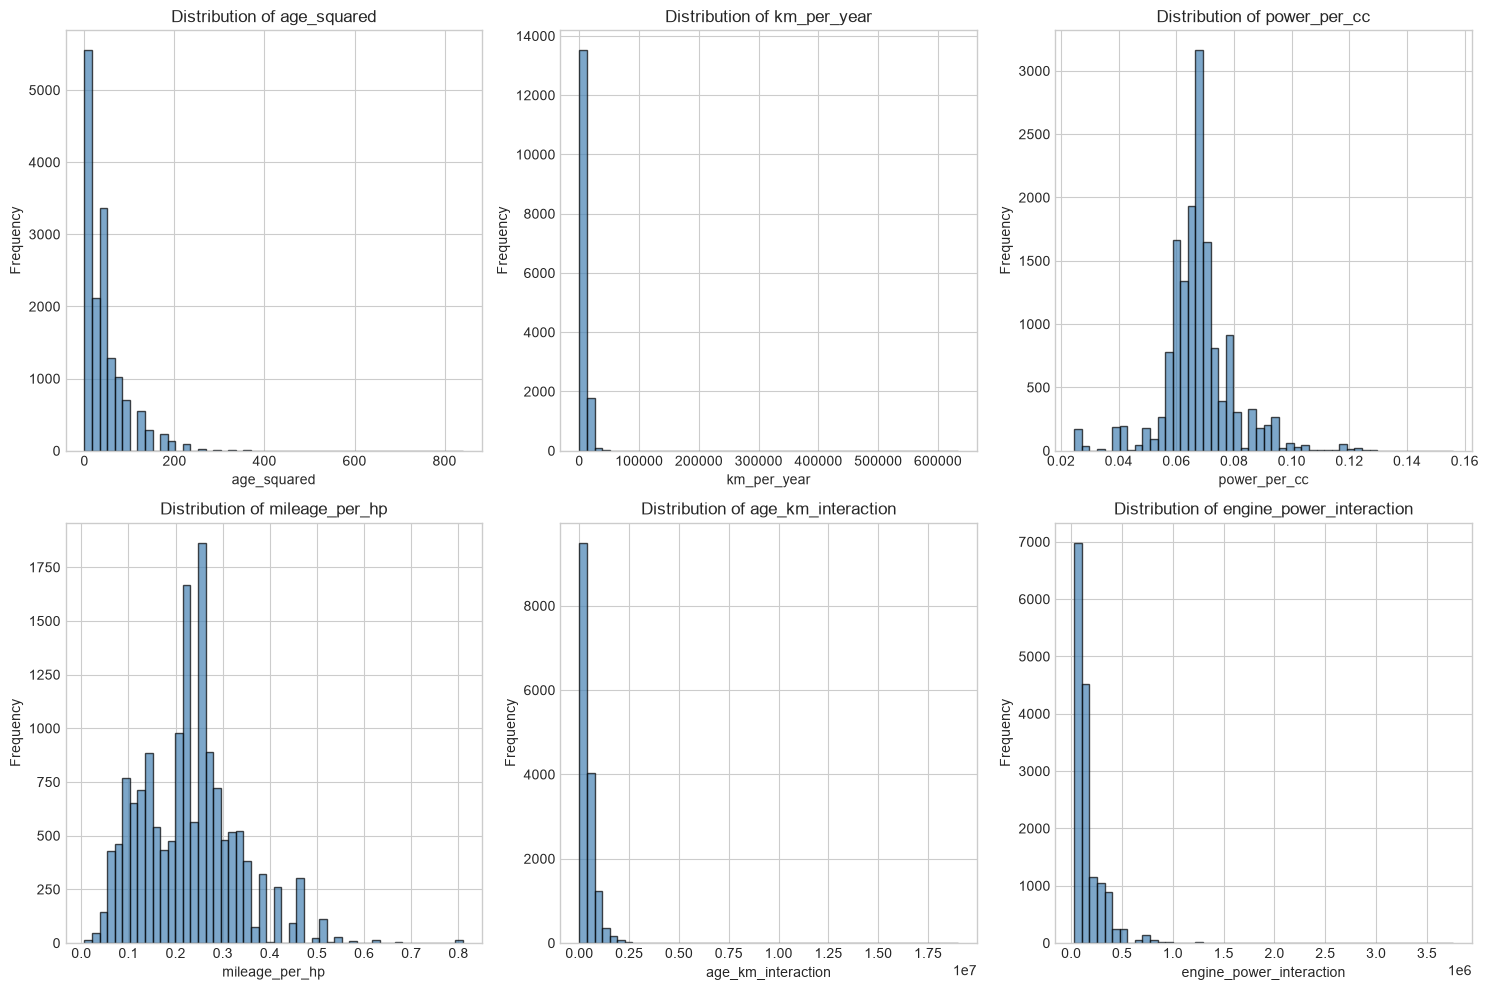

In [7]:
# 4.3 Visualize the new features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(new_numerical_features):
    axes[i].hist(df[feature], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('../reports/figures/new_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# 4.4 Correlation Analysis with Target
print("\n=== Correlation of New Features with Selling Price ===")
correlations = df[new_numerical_features + ['selling_price']].corr()['selling_price'].sort_values(ascending=False)
print(correlations)


=== Correlation of New Features with Selling Price ===
selling_price               1.000000
engine_power_interaction    0.739785
power_per_cc                0.413181
km_per_year                 0.010080
age_km_interaction         -0.151128
age_squared                -0.224229
mileage_per_hp             -0.471907
Name: selling_price, dtype: float64


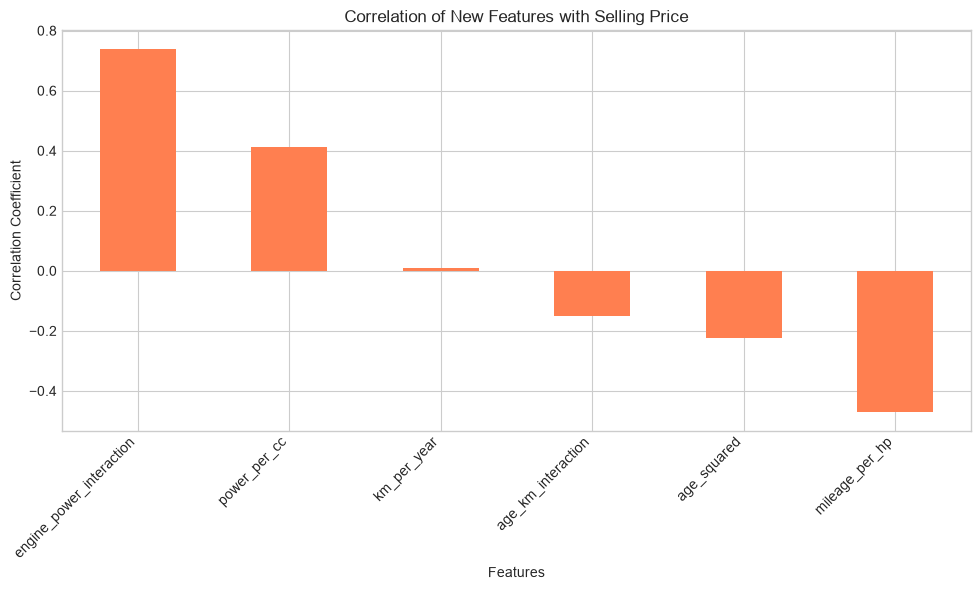

In [10]:
# Visualize correlation with target
plt.figure(figsize=(10, 6))
correlations.drop('selling_price').plot(kind='bar', color='coral')
plt.title('Correlation of New Features with Selling Price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../reports/figures/new_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

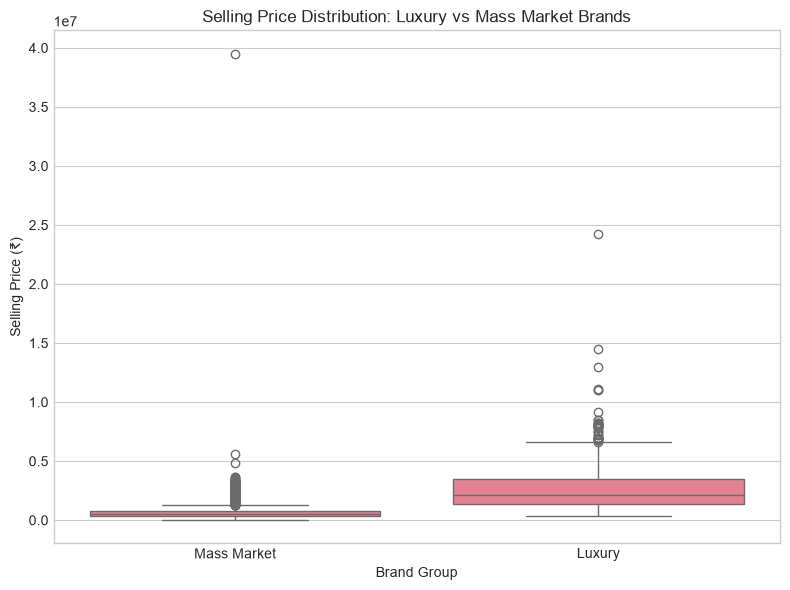

In [11]:
# 4.5 Boxplot of Luxury vs Mass Market
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='brand_group', y='selling_price')
plt.title('Selling Price Distribution: Luxury vs Mass Market Brands')
plt.xlabel('Brand Group')
plt.ylabel('Selling Price (₹)')
plt.tight_layout()
# plt.savefig('../reports/figures/luxury_vs_mass_market.png', dpi=300, bbox_inches='tight')
plt.show()

#### 5. Save the Enhanced Dataset

In [12]:
# Create processed directory if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Save the enhanced dataset
df.to_csv('../data/processed/cardekho_enhanced.csv', index=False)
print("\nEnhanced dataset saved to: ../data/processed/cardekho_enhanced.csv")



Enhanced dataset saved to: ../data/processed/cardekho_enhanced.csv


#### 6. Update Preprocessor Configuration

In [13]:
print("\n" + "="*60)
print("UPDATED PREPROCESSOR CONFIGURATION")
print("="*60)

# Updated categorical features
categorical_features_updated = [
    'brand',           # Existing
    'model',           # Existing
    'seller_type',     # Existing
    'fuel_type',       # Existing
    'transmission_type', # Existing
    'engine_category', # NEW
    'brand_group',     # NEW
    'brand_model'      # NEW
]

# Updated numerical features
numerical_features_updated = [
    'vehicle_age',     # Existing
    'km_driven',       # Existing
    'mileage',         # Existing
    'engine',          # Existing
    'max_power',       # Existing
    'seats',           # Existing
    'age_squared',     # NEW
    'km_per_year',     # NEW
    'power_per_cc',    # NEW
    'mileage_per_hp',  # NEW
    'age_km_interaction', # NEW
    'engine_power_interaction' # NEW
]

print("\nCategorical Features ({} features):".format(len(categorical_features_updated)))
for f in categorical_features_updated:
    print(f"  - {f}")

print("\nNumerical Features ({} features):".format(len(numerical_features_updated)))
for f in numerical_features_updated:
    print(f"  - {f}")

print(f"\nTotal features for preprocessing: {len(categorical_features_updated) + len(numerical_features_updated)}")



UPDATED PREPROCESSOR CONFIGURATION

Categorical Features (8 features):
  - brand
  - model
  - seller_type
  - fuel_type
  - transmission_type
  - engine_category
  - brand_group
  - brand_model

Numerical Features (12 features):
  - vehicle_age
  - km_driven
  - mileage
  - engine
  - max_power
  - seats
  - age_squared
  - km_per_year
  - power_per_cc
  - mileage_per_hp
  - age_km_interaction
  - engine_power_interaction

Total features for preprocessing: 20


#### 7. Feature Importance Analysis (Pre-modeling)

In [14]:
# Let's see how luxury brands affect price
print("\n=== Top 10 Most Expensive Brand-Model Combinations ===")
top_models = df.groupby('brand_model')['selling_price'].median().sort_values(ascending=False).head(10)
print(top_models)

print("\n=== Bottom 10 Most Expensive Brand-Model Combinations ===")
bottom_models = df.groupby('brand_model')['selling_price'].median().sort_values(ascending=True).head(10)
print(bottom_models)


=== Top 10 Most Expensive Brand-Model Combinations ===
brand_model
Ferrari_GTC4Lusso        39500000.0
Rolls-Royce_Ghost        24200000.0
Bentley_Continental       8100000.0
Lexus_RX                  7100000.0
Mercedes-Benz_GLS         6950000.0
Maserati_Ghibli           6200000.0
Maserati_Quattroporte     6000000.0
Porsche_Macan             5985000.0
BMW_X4                    5600000.0
BMW_6                     5550000.0
Name: selling_price, dtype: float64

=== Bottom 10 Most Expensive Brand-Model Combinations ===
brand_model
Hyundai_Santro    240000.0
Maruti_Alto       250000.0
Datsun_RediGO     270000.0
Hyundai_i10       275000.0
Ford_Figo         280000.0
Honda_Civic       295000.0
Maruti_Wagon R    319000.0
Datsun_redi-GO    325000.0
Renault_KWID      345000.0
Maruti_Eeco       349000.0
Name: selling_price, dtype: float64


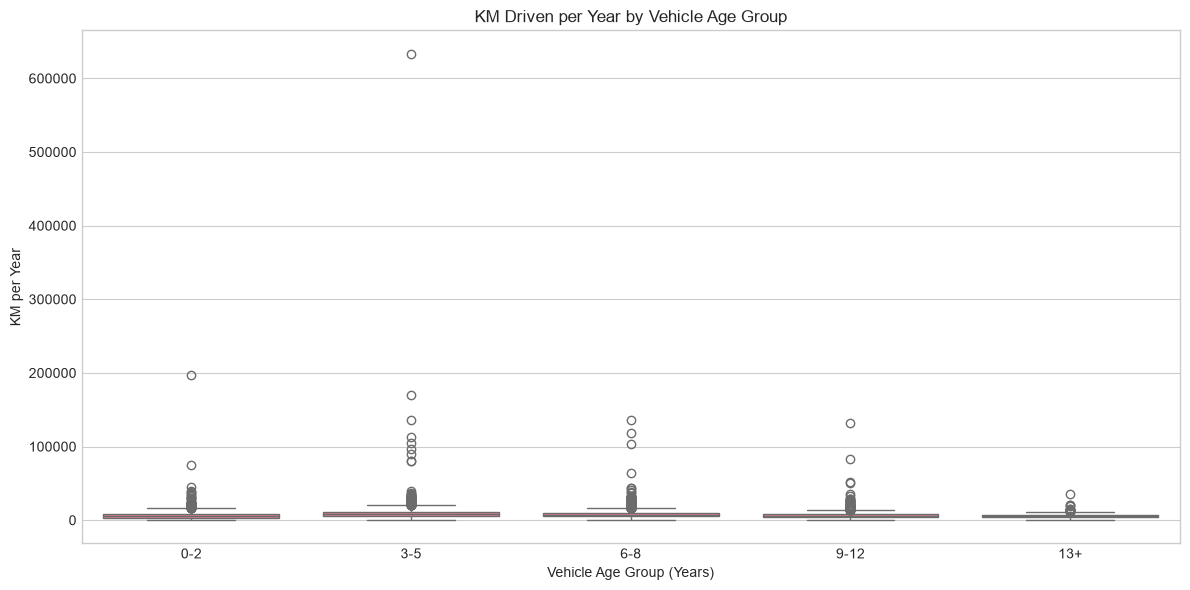

In [15]:
# 7.1 Analyze km_per_year by vehicle age
plt.figure(figsize=(12, 6))
# Create age groups for better visualization
age_groups = pd.cut(df['vehicle_age'], bins=[0, 2, 5, 8, 12, 30], 
                    labels=['0-2', '3-5', '6-8', '9-12', '13+'])
df_temp = df.copy()
df_temp['age_group'] = age_groups

sns.boxplot(data=df_temp, x='age_group', y='km_per_year')
plt.title('KM Driven per Year by Vehicle Age Group')
plt.xlabel('Vehicle Age Group (Years)')
plt.ylabel('KM per Year')
plt.tight_layout()
# plt.savefig('../reports/figures/km_per_year_by_age.png', dpi=300, bbox_inches='tight')
plt.show()


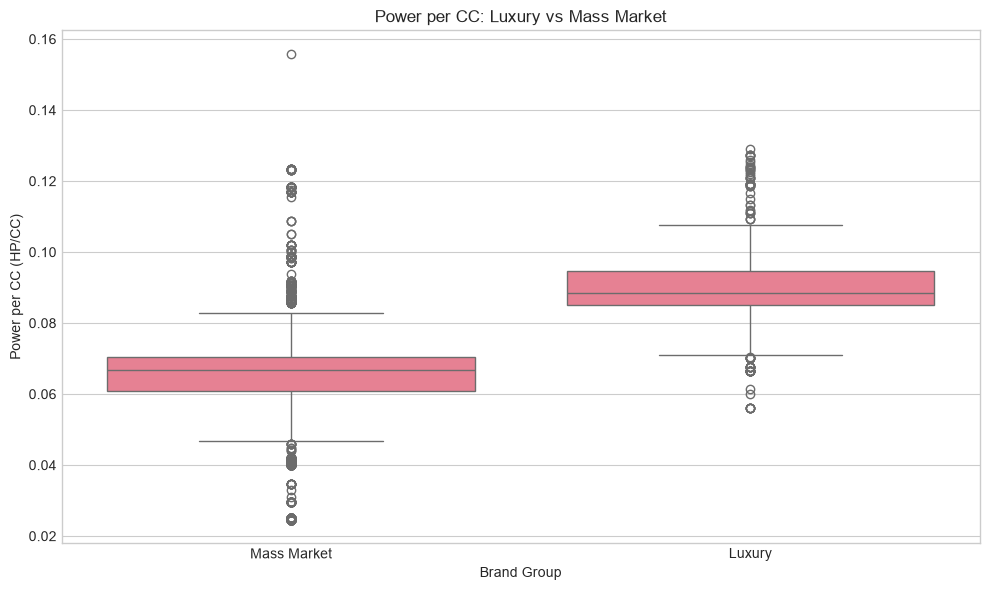

In [17]:
# 7.2 Analyze power_per_cc by brand group
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='brand_group', y='power_per_cc')
plt.title('Power per CC: Luxury vs Mass Market')
plt.xlabel('Brand Group')
plt.ylabel('Power per CC (HP/CC)')
plt.tight_layout()
# plt.savefig('../reports/figures/power_per_cc_by_brand_group.png', dpi=300, bbox_inches='tight')
plt.show()

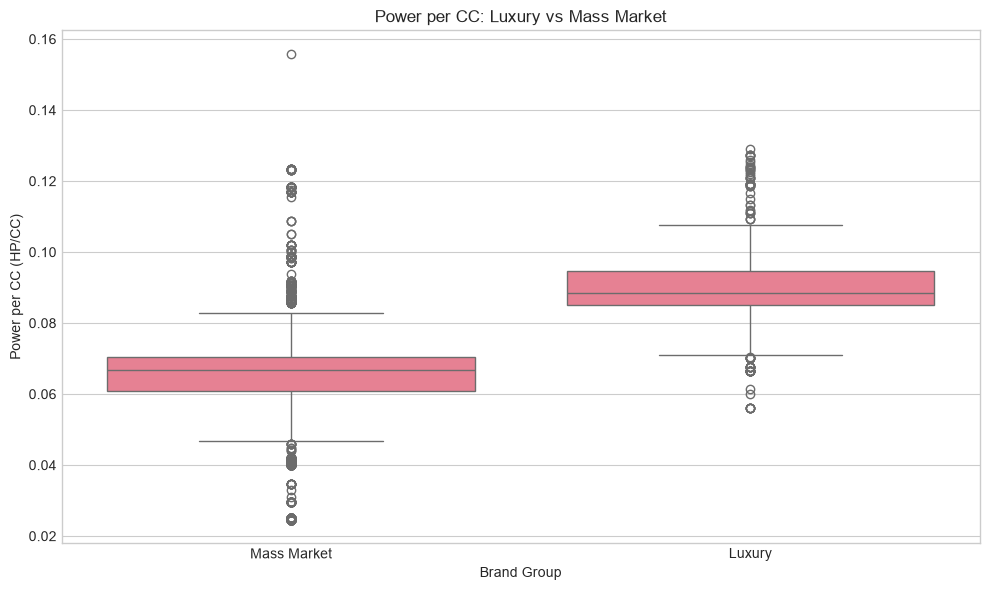


FEATURE ENGINEERING COMPLETE

Key Insights:
1. Created 9 new features to capture non-linear relationships
2. Engine categories and brand groups add domain knowledge
3. Brand-model combinations provide precise model-level pricing
4. Feature interactions help capture complex relationships

Next Steps:
1. Run the preprocessing pipeline with updated features
2. Train models with the enhanced dataset
3. Compare performance with baseline model
4. Perform hyperparameter tuning on the best model


In [19]:
# 7.2 Analyze power_per_cc by brand group
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='brand_group', y='power_per_cc')
plt.title('Power per CC: Luxury vs Mass Market')
plt.xlabel('Brand Group')
plt.ylabel('Power per CC (HP/CC)')
plt.tight_layout()
# plt.savefig('../reports/figures/power_per_cc_by_brand_group.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print("\nKey Insights:")
print("1. Created 9 new features to capture non-linear relationships")
print("2. Engine categories and brand groups add domain knowledge")
print("3. Brand-model combinations provide precise model-level pricing")
print("4. Feature interactions help capture complex relationships")
print("\nNext Steps:")
print("1. Run the preprocessing pipeline with updated features")
print("2. Train models with the enhanced dataset")
print("3. Compare performance with baseline model")
print("4. Perform hyperparameter tuning on the best model")